In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('fatal-police-shootings-data.csv')
df

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,longitude,latitude,is_geocoding_exact
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False,-123.122,47.247,True
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False,-122.892,45.487,True
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False,-97.281,37.695,True
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False,-122.422,37.763,True
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False,-104.692,40.384,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6344,6920,Clay Willingham,2021-06-07,shot,gun,32.0,M,NaN,Jefferson City,MO,False,other,Not fleeing,False,-92.255,38.589,True
6345,6921,Antonio Diaz,2021-06-07,shot,gun,39.0,M,NaN,Round Rock,TX,False,other,NaN,True,-97.687,30.480,True
6346,6922,NaN,2021-06-07,shot,knife,NaN,M,NaN,Bayonne,NJ,True,other,NaN,False,-74.135,40.646,True
6347,6917,Kevin Christopher Caldwell,2021-06-08,shot,gun,33.0,M,NaN,Columbus,GA,False,attack,Car,False,-84.820,32.541,True


# Summary of the Dataset

- id — Unique identifier for each incident
- name — Name of the individual involved in the incident
- date — Date on which the incident occurred
- manner_of_death — How the individual died (e.g., shot, shot and Tasered)
- armed — Type of weapon, if any, found on the individual at the time of the incident
- age — Age of the individual at the time of the incident
- gender — Gender of the individual
- race — Race or ethnicity of the individual
- city — City in which the fatal shooting took place
- state — State in which the fatal shooting took place
- signs_of_mental_illness — Whether the individual showed signs of mental illness during the incident
- threat_level — Level of threat the individual was perceived to pose, as assessed by officers
flee — Whether the individual was attempting to flee at the time of the shooting
body_camera — Whether the incident was recorded by an officer's body camera
longitude / latitude — Geographic coordinates of the incident location
is_geocoding_exact — Whether the recorded geographic coordinates are precisely accurate

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6349 entries, 0 to 6348
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       6349 non-null   int64  
 1   name                     6116 non-null   object 
 2   date                     6349 non-null   object 
 3   manner_of_death          6349 non-null   object 
 4   armed                    6142 non-null   object 
 5   age                      6067 non-null   float64
 6   gender                   6348 non-null   object 
 7   race                     5713 non-null   object 
 8   city                     6349 non-null   object 
 9   state                    6349 non-null   object 
 10  signs_of_mental_illness  6349 non-null   bool   
 11  threat_level             6349 non-null   object 
 12  flee                     5935 non-null   object 
 13  body_camera              6349 non-null   bool   
 14  longitude               

In [4]:
df.isnull().sum()

id                           0
name                       233
date                         0
manner_of_death              0
armed                      207
age                        282
gender                       1
race                       636
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                       414
body_camera                  0
longitude                  307
latitude                   307
is_geocoding_exact           0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning

In [6]:
df.columns = df.columns.str.replace('_',' ').str.title()

In [7]:
df.sample()

,Id,Name,Date,Manner Of Death,Armed,Age,Gender,Race,City,State,Signs Of Mental Illness,Threat Level,Flee,Body Camera,Longitude,Latitude,Is Geocoding Exact
2966,3297,Eugene Loftis,2018-01-08,shot,gun,25.0,M,W,Church Hill,TN,False,other,Not fleeing,False,-82.752,36.579,True


In [8]:
df['Manner Of Death'].value_counts()

Manner Of Death
shot                6025
shot and Tasered     324
Name: count, dtype: int64

In [9]:
df['Armed'].value_counts()

Armed
gun                        3652
knife                       931
unarmed                     407
toy weapon                  216
vehicle                     199
                           ... 
baseball bat and bottle       1
fireworks                     1
pen                           1
chainsaw                      1
knife and vehicle             1
Name: count, Length: 99, dtype: int64

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [12]:
df['Gender'].value_counts()

Gender
M    6069
F     279
Name: count, dtype: int64

In [13]:
df['Race'].value_counts()

Race
W    2896
B    1517
H    1061
A     104
N      88
O      47
Name: count, dtype: int64

In [14]:
df['Signs Of Mental Illness'].value_counts()

Signs Of Mental Illness
False    4893
True     1456
Name: count, dtype: int64

In [15]:
df['Threat Level'].value_counts()

Threat Level
attack          4096
other           2061
undetermined     192
Name: count, dtype: int64

In [16]:
df['Flee'].value_counts()

Flee
Not fleeing    3852
Car            1028
Foot            824
Other           231
Name: count, dtype: int64

In [17]:
df['Body Camera'].value_counts()

Body Camera
False    5504
True      845
Name: count, dtype: int64

In [18]:
df['Is Geocoding Exact'].value_counts()

Is Geocoding Exact
True     6341
False       8
Name: count, dtype: int64

In [19]:
df[['Gender','Race','Flee','Armed']] = df[['Gender','Race','Flee','Armed']].fillna('Unknown')

In [20]:
df['Threat Level'] = df['Threat Level'].astype('category')

In [21]:
df['Flee'] = df['Flee'].astype('category')

In [22]:
df[['Race', 'Gender','Manner Of Death']] = df[['Race', 'Gender','Manner Of Death']].astype('category')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6349 entries, 0 to 6348
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Id                       6349 non-null   int64         
 1   Name                     6116 non-null   object        
 2   Date                     6349 non-null   datetime64[ns]
 3   Manner Of Death          6349 non-null   category      
 4   Armed                    6349 non-null   object        
 5   Age                      6067 non-null   float64       
 6   Gender                   6349 non-null   category      
 7   Race                     6349 non-null   category      
 8   City                     6349 non-null   object        
 9   State                    6349 non-null   object        
 10  Signs Of Mental Illness  6349 non-null   bool          
 11  Threat Level             6349 non-null   category      
 12  Flee                     6349 non-

In [24]:
df.describe()

,Id,Date,Age,Longitude,Latitude,Year,Month
count,6349.000000,6349,6067.000000,6042.000000,6042.000000,6349.000000,6349.000000
mean,3517.354229,2018-03-20 01:54:32.263348736,37.087193,-97.178956,36.658589,2017.741062,6.222870
min,3.000000,2015-01-02 00:00:00,6.000000,-158.137000,19.498000,2015.000000,1.000000
25%,1795.000000,2016-08-09 00:00:00,27.000000,-112.099750,33.469250,2016.000000,3.000000
50%,3526.000000,2018-03-16 00:00:00,35.000000,-94.356000,36.103000,2018.000000,6.000000
75%,5244.000000,2019-11-05 00:00:00,45.000000,-83.120250,39.995000,2019.000000,9.000000
max,6924.000000,2021-06-09 00:00:00,91.000000,-67.867000,71.301000,2021.000000,12.000000
std,1984.876790,NaN,12.998319,16.610601,5.379140,1.862487,3.488834


In [25]:
df[df['Age'] ==6]

,Id,Name,Date,Manner Of Death,Armed,Age,Gender,Race,City,State,Signs Of Mental Illness,Threat Level,Flee,Body Camera,Longitude,Latitude,Is Geocoding Exact,Year,Month
833,980,Jeremy Mardis,2015-11-03,shot,unarmed,6.0,M,W,Marksville,LA,False,other,Car,True,-92.050,31.125,True,2015,11
2905,3229,Kameron Prescott,2017-12-21,shot,unarmed,6.0,M,W,Schertz,TX,False,other,Not fleeing,False,-98.257,29.552,True,2017,12


In [26]:
df[df['Age'] == 91]

,Id,Name,Date,Manner Of Death,Armed,Age,Gender,Race,City,State,Signs Of Mental Illness,Threat Level,Flee,Body Camera,Longitude,Latitude,Is Geocoding Exact,Year,Month
2159,2407,Frank W. Wratny,2017-03-08,shot,gun,91.0,M,W,Union Township,PA,False,attack,Not fleeing,False,-79.998,40.259,True,2017,3
5970,6488,Betty Francois,2021-01-09,shot,gun,91.0,F,W,Victorville,CA,False,attack,Not fleeing,False,-117.293,34.536,True,2021,1


In [27]:
df['Name'] = df['Name'].fillna('Unknown')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6349 entries, 0 to 6348
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Id                       6349 non-null   int64         
 1   Name                     6349 non-null   object        
 2   Date                     6349 non-null   datetime64[ns]
 3   Manner Of Death          6349 non-null   category      
 4   Armed                    6349 non-null   object        
 5   Age                      6067 non-null   float64       
 6   Gender                   6349 non-null   category      
 7   Race                     6349 non-null   category      
 8   City                     6349 non-null   object        
 9   State                    6349 non-null   object        
 10  Signs Of Mental Illness  6349 non-null   bool          
 11  Threat Level             6349 non-null   category      
 12  Flee                     6349 non-

# Performing EDA


# Univariate Analysis

Text(0.5, 1.0, "Encountered People's Race")

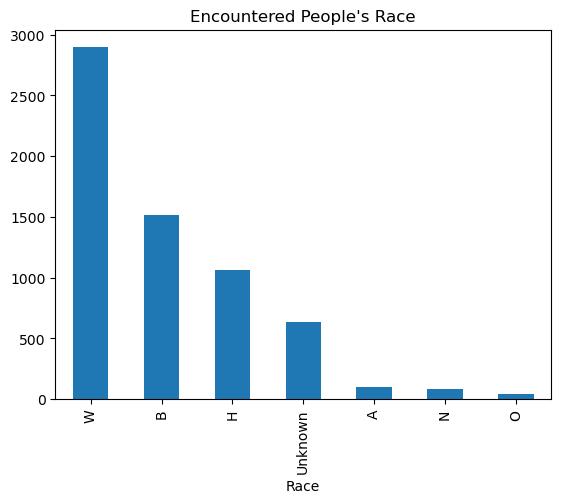

In [29]:
df['Race'].value_counts().plot(kind = 'bar')
plt.title("Encountered People's Race")

Text(0.5, 1.0, 'Manner Of Death')

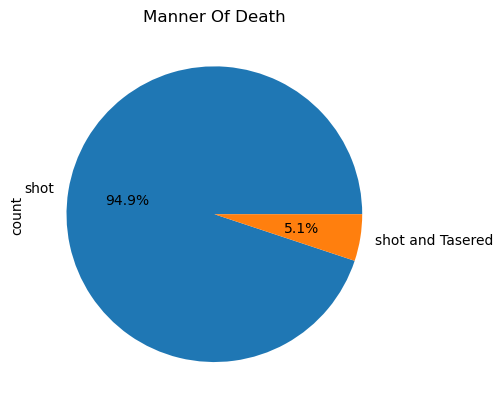

In [30]:
df['Manner Of Death'].value_counts().plot(kind = 'pie',autopct ='%0.1f%%' )
plt.title('Manner Of Death')

Text(0, 0.5, 'Number of Criminals')

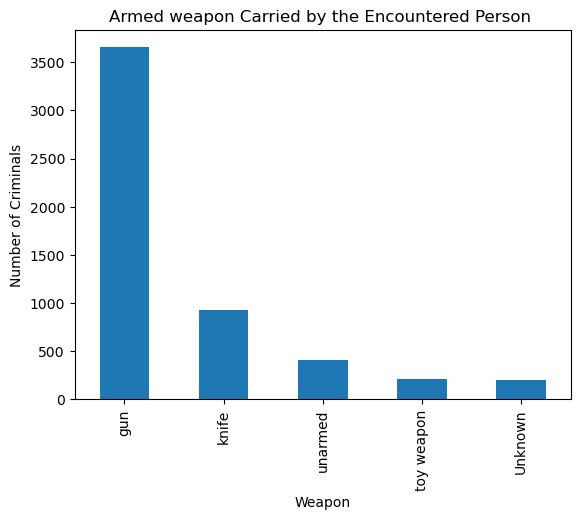

In [31]:
df['Armed'].value_counts().head().plot(kind='bar')
plt.title('Armed weapon Carried by the Encountered Person ')
plt.xlabel('Weapon')
plt.ylabel('Number of Criminals')

Text(0.5, 1.0, 'Death Count Based on Age')

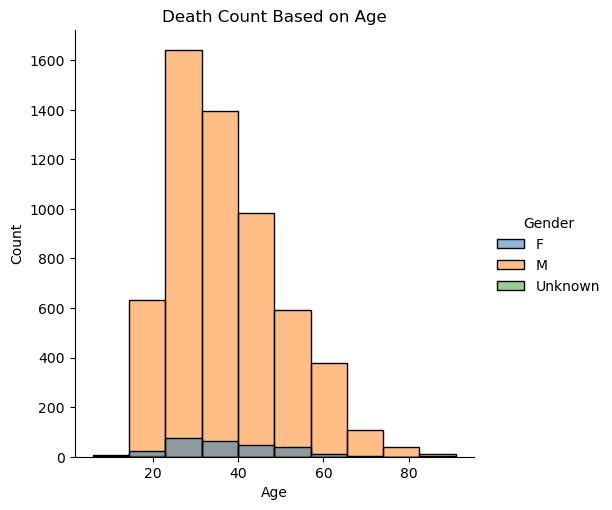

In [32]:
sns.displot(kind = 'hist', data = df, x ='Age' , hue='Gender', bins = 10)
plt.title('Death Count Based on Age')

Text(0.5, 1.0, 'fatal shooting based on Geographical location')

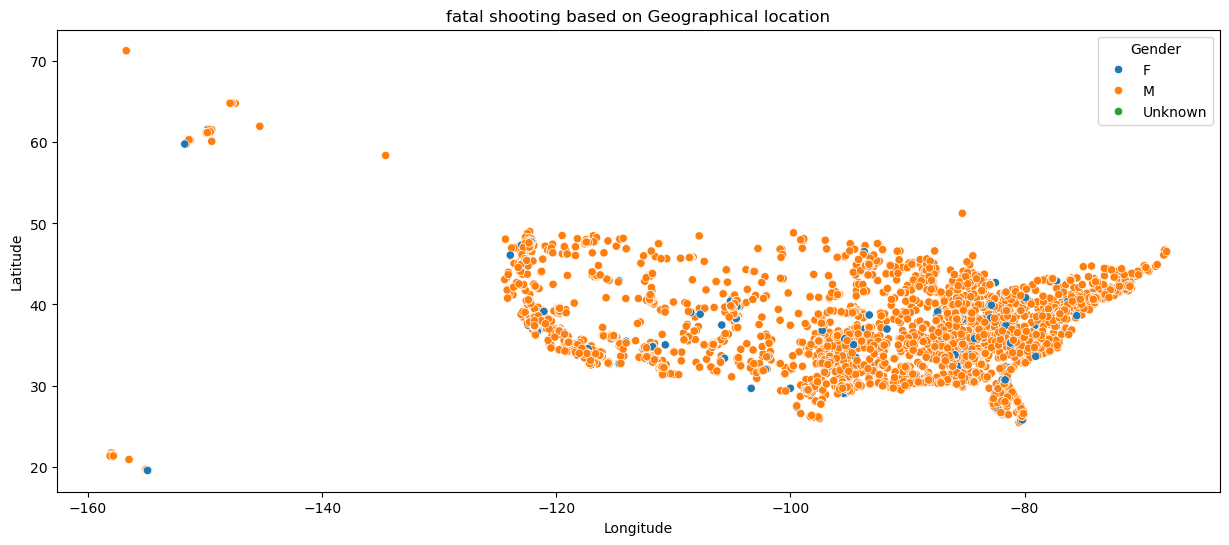

In [33]:
plt.figure(figsize=(15,6))
sns.scatterplot(data = df, x = 'Longitude', y ='Latitude', hue='Gender')
plt.title('fatal shooting based on Geographical location')

In [34]:
df.sample()

,Id,Name,Date,Manner Of Death,Armed,Age,Gender,Race,City,State,Signs Of Mental Illness,Threat Level,Flee,Body Camera,Longitude,Latitude,Is Geocoding Exact,Year,Month
4385,4800,Juan Carlos Chapa,2019-06-20,shot,gun,33.0,M,H,Mission,TX,True,attack,Foot,False,-98.302,26.212,True,2019,6


In [35]:
df[df['Gender'] == 'Unknown']

,Id,Name,Date,Manner Of Death,Armed,Age,Gender,Race,City,State,Signs Of Mental Illness,Threat Level,Flee,Body Camera,Longitude,Latitude,Is Geocoding Exact,Year,Month
2655,2956,Scout Schultz,2017-09-16,shot,knife,21.0,Unknown,W,Atlanta,GA,True,other,Not fleeing,False,NaN,NaN,True,2017,9


Text(0.5, 1.0, 'Cities with the Least Fatal Shooting')

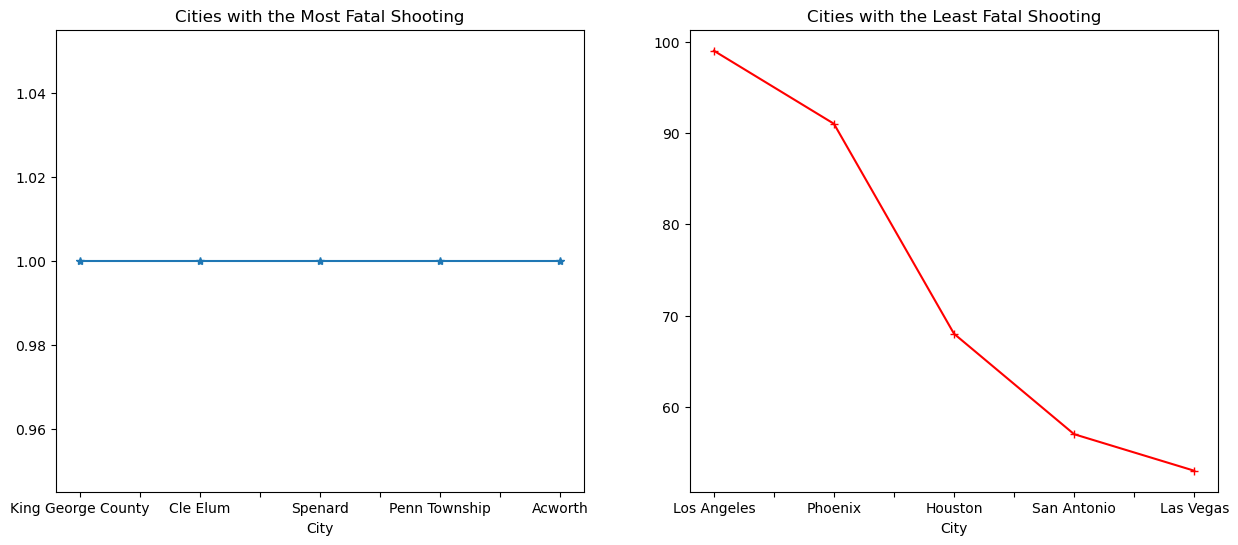

In [36]:
# top 10city with the most and least fatal shooting
fig,ax = plt.subplots(ncols = 2, figsize = (15,6))
df['City'].value_counts().sort_values(ascending = True).head().plot(ax=ax[0], marker = '*')
df['City'].value_counts().sort_values(ascending = False).head().plot(ax=ax[1], marker = "+", color = 'red')
ax[0].set_title('Cities with the Most Fatal Shooting')
ax[1].set_title('Cities with the Least Fatal Shooting')

Text(0.5, 1.0, 'City with Most Mentally Ill Fatal Shooted Persons ')

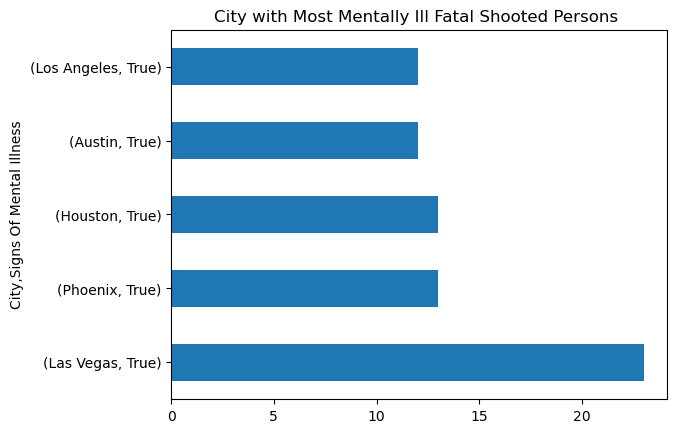

In [37]:
data = df[df['Signs Of Mental Illness'] == True].groupby('City')['Signs Of Mental Illness'].value_counts().sort_values(ascending = False).head()
data.plot(kind = 'barh')
plt.title('City with Most Mentally Ill Fatal Shooted Persons ')

C:\Users\23shr\AppData\Local\Temp\ipykernel_7404\1141966389.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Threat Level')['Armed'].value_counts().sort_values(ascending = False).head().plot(kind='barh')


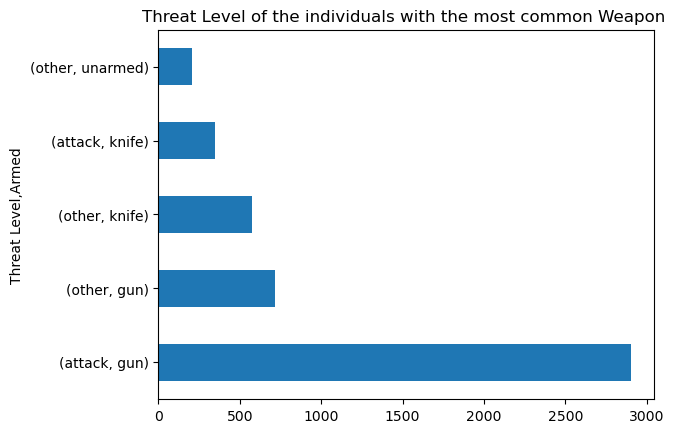

In [38]:
df.groupby('Threat Level')['Armed'].value_counts().sort_values(ascending = False).head().plot(kind='barh')
plt.title('Threat Level of the individuals with the most common Weapon ')
plt.show()

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6349 entries, 0 to 6348
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Id                       6349 non-null   int64         
 1   Name                     6349 non-null   object        
 2   Date                     6349 non-null   datetime64[ns]
 3   Manner Of Death          6349 non-null   category      
 4   Armed                    6349 non-null   object        
 5   Age                      6067 non-null   float64       
 6   Gender                   6349 non-null   category      
 7   Race                     6349 non-null   category      
 8   City                     6349 non-null   object        
 9   State                    6349 non-null   object        
 10  Signs Of Mental Illness  6349 non-null   bool          
 11  Threat Level             6349 non-null   category      
 12  Flee                     6349 non-

<Axes: xlabel='Year'>

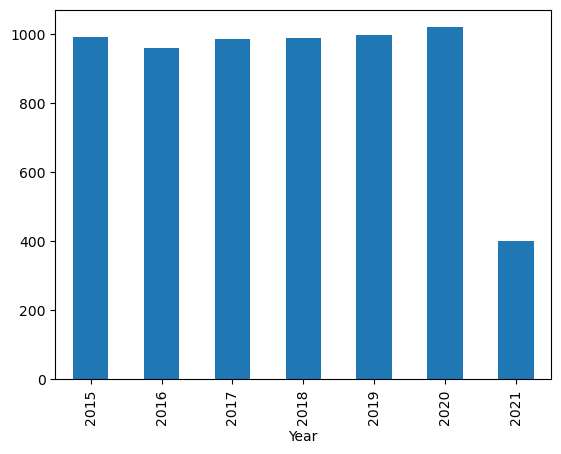

In [56]:
df['Year'].value_counts().sort_index().plot(kind ='bar')

<Axes: xlabel='Month'>

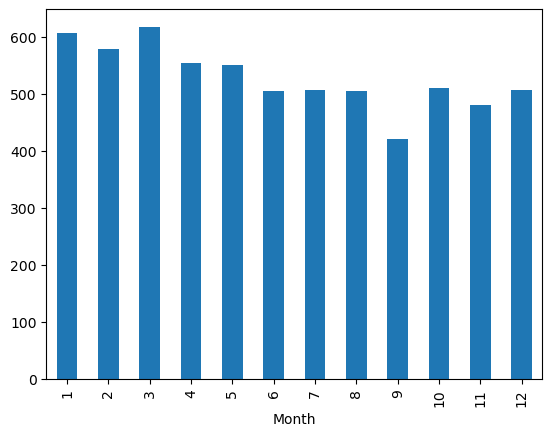

In [55]:
df['Month'].value_counts().sort_index().plot(kind ='bar')


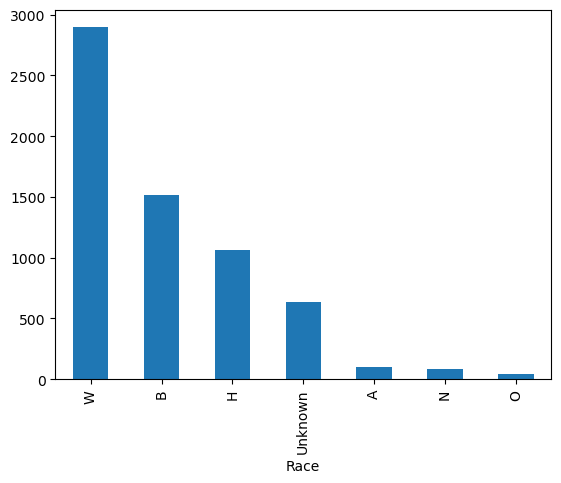

In [57]:
# Raw counts by race
df['Race'].value_counts().plot(kind='bar')

# Normalize by US population share for fair comparison
pop_share = {
    'White': 0.601, 'Black': 0.134, 'Hispanic': 0.185,
    'Asian': 0.059, 'Native American': 0.013
}
# Compare shootings % vs population %

<Axes: xlabel='Race'>

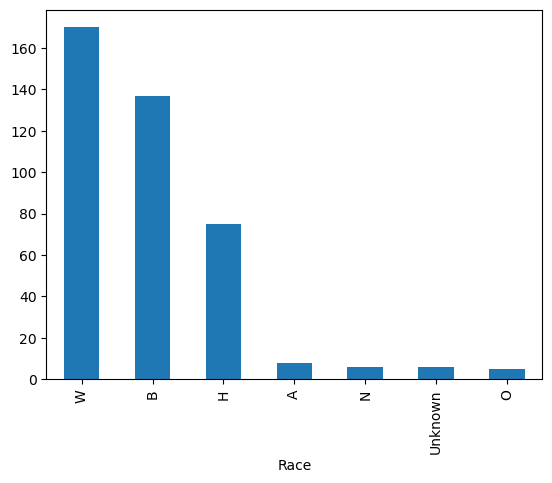

In [63]:
df['Armed'].value_counts().head(10)   # what weapons were involved

# Unarmed killed — critical insight
df[df['Armed'] == 'unarmed']['Race'].value_counts().plot(kind = 'bar')

<Axes: title={'center': 'Age'}, xlabel='Race'>

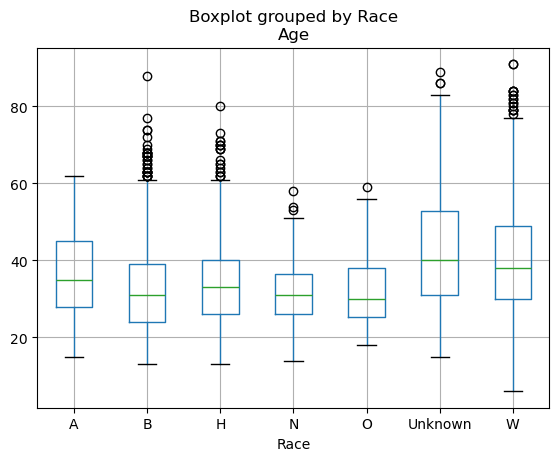

In [65]:
df.boxplot(column='Age', by='Race')

In [67]:
# Race vs armed status
pd.crosstab(df['Race'], df['Armed'] == 'unarmed', normalize='index')

Armed,False,True
Race,,
A,0.923077,0.076923
B,0.909690,0.090310
H,0.929312,0.070688
N,0.931818,0.068182
O,0.893617,0.106383
Unknown,0.990566,0.009434
W,0.941298,0.058702


In [69]:
# Race vs flee
pd.crosstab(df['Race'], df['Flee'], normalize='index')

Flee,Car,Foot,Not fleeing,Other,Unknown
Race,,,,,
A,0.086538,0.096154,0.759615,0.009615,0.048077
B,0.160185,0.197759,0.553065,0.038893,0.050099
H,0.166824,0.140434,0.583412,0.043355,0.065975
N,0.113636,0.181818,0.556818,0.034091,0.113636
O,0.212766,0.106383,0.617021,0.042553,0.021277
Unknown,0.165094,0.099057,0.561321,0.047170,0.127358
W,0.163674,0.097030,0.649171,0.031077,0.059047
